<a href="https://colab.research.google.com/github/alina518/Projects/blob/main/Multimodal_Parkinsons_Risk_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multimodal Explainable Machine Learning for Parkinson's Disease Risk Assessment

**Type:** Research / educational demonstration notebook
**Author:** Generated with Claude
**Reproducibility:** `random_state = 42` everywhere

> ⚠️ **DISCLAIMER — READ FIRST**
> This notebook is a **research and educational demonstration only**. It is **NOT a clinically validated diagnostic tool** and must **NEVER** be used to diagnose, screen, or make any clinical decision about a real patient. The "risk fusion" score at the end is a **toy illustration of weighted score combination**, not a validated multimodal biomarker model. Always consult a qualified neurologist for Parkinson's disease diagnosis.

## What this notebook does
Four **independent** models are trained on four **independent, publicly available datasets**, each representing a different data modality that has been studied in the Parkinson's disease (PD) literature:

| Module | Modality | Dataset | Access |
|---|---|---|---|
| 1 | Gene expression | NCBI GEO **GSE99039** (blood expression, PD vs. control) | Public, no login, via `GEOparse` |
| 2 | Voice / acoustic | UCI **Parkinson's Disease Data Set** (Little et al., 2007) | Public, no login, direct URL |
| 3 | "Clinical" (speech-derived clinical assessment protocol) | UCI **Parkinson's Disease Classification** dataset (Sakar et al., 2018, UCI ID 470) | Public, no login, direct URL |
| 4 | Lifestyle / risk-factor | Attempted via Kaggle (`kagglehub`, anonymous access) | Public **if** available — see honesty note below |

### Honesty note on dataset choice (please read)
Two genuinely independent, **fully public, credential-free, programmatically downloadable** datasets covering *clinical exam* and *lifestyle/risk-factor* modalities for Parkinson's disease are hard to find:

- **PPMI** (Parkinson's Progression Markers Initiative) requires a **manual account registration and data-use agreement** — it **cannot** be downloaded automatically/anonymously, so per the project instructions we substitute another public dataset for Module 3.
- The Module 3 substitute (**UCI ID 470**, Sakar et al. 2018) is still **speech-derived** at the raw-signal level, but it is engineered and published as a distinct **clinical assessment protocol** (structured tests, not free speech, with demographic/clinical metadata such as age, gender and multiple recording sessions), and is treated in the literature as a separate dataset/module from the classic Little et al. dataset used in Module 2. We flag this overlap explicitly rather than pretend the modalities are fully independent.
- For **Module 4 (lifestyle)**, we attempt an anonymous `kagglehub` download of a public PD lifestyle/risk-factor dataset. Kaggle datasets can change availability/licensing at any time and some require an API token. The notebook **does not fabricate data**: if the download fails or no suitable public dataset is reachable in your environment, Module 4 will print a clear explanation and **skip model training**, exactly as required.

## Notebook structure
1. Install dependencies
2. Imports
3. Configuration
4. Project folder structure
5. Automatic dataset download utilities
6. Module 1 — Gene Expression Model
7. Module 2 — Voice Biomarker Model
8. Module 3 — Clinical Model
9. Module 4 — Lifestyle Model (best-effort)
10. Model Comparison
11. Risk Fusion Demonstration
12. Conclusions


## 1. Install Dependencies

In [ ]:
# Install packages not preinstalled in Google Colab.
# (Colab already ships pandas, numpy, matplotlib, scipy, scikit-learn.)
!pip install -q GEOparse xgboost catboost shap kagglehub plotly joblib
print("Dependencies installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00
Dependencies installed.


## 2. Imports

In [ ]:
import os
import sys
import time
import shutil
import zipfile
import logging
import warnings
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay
)

import xgboost as xgb
from catboost import CatBoostClassifier
import shap
import joblib

warnings.filterwarnings("ignore")
np.random.seed(42)

print("All libraries imported successfully.")
print(f"xgboost {xgb.__version__}, shap {shap.__version__} ready.")


All libraries imported successfully.
xgboost 3.3.0, shap 0.52.0 ready.


## 3. Configuration

In [ ]:
# ---------------------------------------------------------------
# Central configuration. Change dataset IDs here if a source becomes
# unavailable; every downstream cell reads from this dict only.
# ---------------------------------------------------------------
CONFIG = {
    "GENETICS_DATASET": "GSE99039",  # NCBI GEO accession: PD vs control whole-blood expression
    "VOICE_DATASET_URL": "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data",
    "CLINICAL_DATASET_ZIP_URL": "https://archive.ics.uci.edu/static/public/470/parkinson+s+disease+classification.zip",
    "LIFESTYLE_KAGGLE_HANDLES": [
        # Best-effort candidates; kagglehub will try these in order.
        "andrewmvd/parkinsons-disease-dataset",
        "vikasukani/parkinsons-disease-data-set",
    ],
    "TEST_SIZE": 0.2,
    "RANDOM_STATE": 42,
    "N_JOBS": -1,
    "CV_FOLDS": 5,
}

RANDOM_STATE = CONFIG["RANDOM_STATE"]
TEST_SIZE = CONFIG["TEST_SIZE"]

print("Configuration loaded:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


Configuration loaded:
  GENETICS_DATASET: GSE99039
  VOICE_DATASET_URL: https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data
  CLINICAL_DATASET_ZIP_URL: https://archive.ics.uci.edu/static/public/470/parkinson+s+disease+classification.zip
  LIFESTYLE_KAGGLE_HANDLES: ['andrewmvd/parkinsons-disease-dataset', 'vikasukani/parkinsons-disease-data-set']
  TEST_SIZE: 0.2
  RANDOM_STATE: 42
  N_JOBS: -1
  CV_FOLDS: 5


## 4. Project Folder Structure

In [ ]:
BASE_DIR = Path("project")

FOLDERS = [
    BASE_DIR / "datasets" / "genetics",
    BASE_DIR / "datasets" / "voice",
    BASE_DIR / "datasets" / "clinical",
    BASE_DIR / "datasets" / "lifestyle",
    BASE_DIR / "saved_models",
    BASE_DIR / "plots",
    BASE_DIR / "shap",
    BASE_DIR / "reports",
    BASE_DIR / "logs",
]

for folder in FOLDERS:
    folder.mkdir(parents=True, exist_ok=True)

# Logging setup -> project/logs/pipeline.log
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(BASE_DIR / "logs" / "pipeline.log"),
        logging.StreamHandler(sys.stdout),
    ],
)
logger = logging.getLogger("pd_pipeline")

print("Project folder structure created:")
for folder in FOLDERS:
    print(f"  {folder}/")


Project folder structure created:
  project/datasets/genetics/
  project/datasets/voice/
  project/datasets/clinical/
  project/datasets/lifestyle/
  project/saved_models/
  project/plots/
  project/shap/
  project/reports/
  project/logs/


## 5. Automatic Dataset Download Utilities

Reusable, defensive download helpers. Every function:
- Skips downloading if the target file/folder already exists.
- Wraps network calls in `try/except` and logs failures instead of crashing the notebook.
- Returns `None` on failure so downstream modules can check and respond gracefully.


In [ ]:
import urllib.request
import ssl

def _download_file(url: str, dest_path: Path, timeout: int = 60) -> bool:
    """Download a single file with graceful failure handling.

    Returns True on success (or if the file already exists), False otherwise.
    """
    if dest_path.exists() and dest_path.stat().st_size > 0:
        logger.info(f"[SKIP] {dest_path.name} already exists.")
        return True
    try:
        logger.info(f"Downloading {url} -> {dest_path}")
        ctx = ssl.create_default_context()
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=timeout, context=ctx) as response, open(dest_path, "wb") as out_file:
            shutil.copyfileobj(response, out_file)
        logger.info(f"Downloaded {dest_path.name} successfully.")
        return True
    except Exception as e:
        logger.error(f"Failed to download {url}: {e}")
        return False


def _unzip_file(zip_path: Path, extract_to: Path) -> bool:
    """Unzip a file automatically; returns True on success."""
    try:
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_to)
        logger.info(f"Extracted {zip_path.name} -> {extract_to}")
        return True
    except Exception as e:
        logger.error(f"Failed to extract {zip_path}: {e}")
        return False


def download_geo_dataset(accession: str, dest_dir: Path):
    """Download a GEO series using GEOparse. Falls back to direct FTP soft-matrix
    download if GEOparse itself fails. Returns a GEOparse GSE object or None.
    """
    dest_dir.mkdir(parents=True, exist_ok=True)
    try:
        import GEOparse
        soft_file = dest_dir / f"{accession}_family.soft.gz"
        if soft_file.exists():
            logger.info(f"[SKIP] {accession} already downloaded.")
        gse = GEOparse.get_GEO(geo=accession, destdir=str(dest_dir), silent=True)
        logger.info(f"GEO dataset {accession} loaded: {len(gse.gsms)} samples, {len(gse.gpls)} platforms.")
        return gse
    except Exception as e:
        logger.error(f"GEOparse failed for {accession}: {e}")
        logger.error(traceback.format_exc())
        return None


def download_voice_dataset(url: str, dest_dir: Path) -> Path:
    """Download the UCI voice dataset CSV. Returns local path or None."""
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest_path = dest_dir / "parkinsons.data"
    ok = _download_file(url, dest_path)
    return dest_path if ok else None


def download_clinical_dataset(url: str, dest_dir: Path) -> Path:
    """Download + unzip the UCI clinical (Sakar et al. 2018) dataset. Returns the
    extraction directory or None.
    """
    dest_dir.mkdir(parents=True, exist_ok=True)
    zip_path = dest_dir / "clinical_raw.zip"
    ok = _download_file(url, zip_path)
    if not ok:
        return None
    extract_dir = dest_dir / "extracted"
    extract_dir.mkdir(exist_ok=True)
    if not any(extract_dir.iterdir()):
        unzip_ok = _unzip_file(zip_path, extract_dir)
        if not unzip_ok:
            return None
    return extract_dir


def download_lifestyle_dataset(handles, dest_dir: Path):
    """Best-effort anonymous Kaggle download via kagglehub. Tries multiple dataset
    handles in order. Returns (local_path, handle_used) or (None, None) if every
    attempt fails -- this is expected/handled, not a crash.
    """
    dest_dir.mkdir(parents=True, exist_ok=True)
    try:
        import kagglehub
    except Exception as e:
        logger.warning(f"kagglehub unavailable: {e}")
        return None, None

    for handle in handles:
        try:
            logger.info(f"Attempting anonymous Kaggle download: {handle}")
            path = kagglehub.dataset_download(handle)
            logger.info(f"Lifestyle dataset downloaded from '{handle}' -> {path}")
            return Path(path), handle
        except Exception as e:
            logger.warning(f"Kaggle handle '{handle}' failed: {e}")
            continue

    logger.warning("All Kaggle lifestyle dataset attempts failed.")
    return None, None


print("Download utility functions defined.")


Download utility functions defined.


## 5b. Shared Evaluation, Plotting and Results-Tracking Helpers

In [ ]:
PLOTS_DIR = BASE_DIR / "plots"
SHAP_DIR = BASE_DIR / "shap"
MODELS_DIR = BASE_DIR / "saved_models"
REPORTS_DIR = BASE_DIR / "reports"

# Global registry of results across all modules -> used for the comparison table.
RESULTS = []


def evaluate_classifier(name, dataset, model, X_train, X_test, y_train, y_test, fit_time=None):
    """Fit (if needed) and evaluate a classifier, returning a metrics dict and
    appending a row to the global RESULTS registry.
    """
    t0 = time.time()
    if fit_time is None:
        model.fit(X_train, y_train)
        fit_time = time.time() - t0

    t1 = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - t1

    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        y_proba = None
        auc = np.nan

    try:
        cv_scores = cross_val_score(
            model, np.vstack([X_train, X_test]) if isinstance(X_train, np.ndarray) else pd.concat([X_train, X_test]),
            np.concatenate([y_train, y_test]) if isinstance(y_train, np.ndarray) else pd.concat([y_train, y_test]),
            cv=StratifiedKFold(n_splits=CONFIG["CV_FOLDS"], shuffle=True, random_state=RANDOM_STATE),
            scoring="accuracy", n_jobs=CONFIG["N_JOBS"],
        )
        cv_mean = cv_scores.mean()
    except Exception as e:
        logger.warning(f"CV failed for {dataset}/{name}: {e}")
        cv_mean = np.nan

    metrics = {
        "Dataset": dataset,
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": auc,
        "CV_Accuracy": cv_mean,
        "Train_Time_s": round(fit_time, 4),
        "Predict_Time_s": round(pred_time, 6),
    }
    RESULTS.append(metrics)
    logger.info(f"[{dataset}/{name}] " + ", ".join(f"{k}={v:.4f}" for k, v in metrics.items() if isinstance(v, float)))
    return model, metrics, y_pred, y_proba


def plot_class_distribution(y, dataset_name):
    fig, ax = plt.subplots(figsize=(5, 4))
    pd.Series(y).value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
    ax.set_title(f"{dataset_name}: Class Distribution")
    ax.set_xlabel("Class (0=Control/Neg, 1=PD/Pos)")
    ax.set_ylabel("Count")
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"{dataset_name}_class_distribution.png", dpi=120)
    plt.show()
    plt.close(fig)


def plot_missing_heatmap(df, dataset_name):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.imshow(df.isna(), aspect="auto", cmap="viridis")
    ax.set_title(f"{dataset_name}: Missing Value Heatmap")
    ax.set_xlabel("Features")
    ax.set_ylabel("Samples")
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"{dataset_name}_missing_heatmap.png", dpi=120)
    plt.show()
    plt.close(fig)


def plot_correlation_heatmap(df, dataset_name, max_features=40):
    numeric_df = df.select_dtypes(include=[np.number])
    if numeric_df.shape[1] > max_features:
        numeric_df = numeric_df.iloc[:, :max_features]
    corr = numeric_df.corr()
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(f"{dataset_name}: Correlation Heatmap (first {numeric_df.shape[1]} features)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"{dataset_name}_correlation_heatmap.png", dpi=120)
    plt.show()
    plt.close(fig)


def plot_pca_visualization(X, y, dataset_name):
    pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
    X2 = pca2.fit_transform(X)
    fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap="coolwarm", alpha=0.7, edgecolor="k")
    ax.set_title(f"{dataset_name}: PCA (2 components)")
    ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
    legend1 = ax.legend(*scatter.legend_elements(), title="Class")
    ax.add_artist(legend1)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"{dataset_name}_pca.png", dpi=120)
    plt.show()
    plt.close(fig)


def plot_roc_curve(model, X_test, y_test, name, dataset_name):
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
    except Exception:
        return
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_title(f"{dataset_name}: ROC Curve")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"{dataset_name}_{name}_roc.png", dpi=120)
    plt.show()
    plt.close(fig)


def plot_pr_curve(model, X_test, y_test, name, dataset_name):
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
    except Exception:
        return
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(recall, precision, label=name)
    ax.set_title(f"{dataset_name}: Precision-Recall Curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"{dataset_name}_{name}_pr.png", dpi=120)
    plt.show()
    plt.close(fig)


def plot_confusion(model, X_test, y_test, name, dataset_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(f"{dataset_name}: {name} Confusion Matrix")
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"{dataset_name}_{name}_confusion.png", dpi=120)
    plt.show()
    plt.close(fig)


def plot_feature_importance(model, feature_names, name, dataset_name, top_n=20):
    importances = None
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_).ravel()
    if importances is None:
        return
    order = np.argsort(importances)[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(7, max(4, 0.3 * len(order))))
    ax.barh(np.array(feature_names)[order][::-1], importances[order][::-1], color="#55A868")
    ax.set_title(f"{dataset_name}: {name} Feature Importance (top {len(order)})")
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"{dataset_name}_{name}_feature_importance.png", dpi=120)
    plt.show()
    plt.close(fig)


def run_shap_explainability(model, X_train, X_test, feature_names, name, dataset_name, model_type="tree"):
    """Compute and save SHAP summary + bar plots. Falls back to KernelExplainer
    for non-tree models on a small background sample (for runtime reasons).
    """
    try:
        X_test_df = pd.DataFrame(X_test, columns=feature_names) if not isinstance(X_test, pd.DataFrame) else X_test
        X_train_df = pd.DataFrame(X_train, columns=feature_names) if not isinstance(X_train, pd.DataFrame) else X_train

        if model_type == "tree":
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test_df)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            background = shap.sample(X_train_df, min(50, len(X_train_df)), random_state=RANDOM_STATE)
            explainer = shap.KernelExplainer(model.predict_proba, background)
            shap_values = explainer.shap_values(X_test_df.iloc[: min(50, len(X_test_df))], nsamples=100)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
            X_test_df = X_test_df.iloc[: min(50, len(X_test_df))]

        plt.figure()
        shap.summary_plot(shap_values, X_test_df, show=False)
        plt.title(f"{dataset_name}: {name} SHAP Summary")
        plt.tight_layout()
        plt.savefig(SHAP_DIR / f"{dataset_name}_{name}_shap_summary.png", dpi=120, bbox_inches="tight")
        plt.show()
        plt.close()

        plt.figure()
        shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False)
        plt.title(f"{dataset_name}: {name} SHAP Bar")
        plt.tight_layout()
        plt.savefig(SHAP_DIR / f"{dataset_name}_{name}_shap_bar.png", dpi=120, bbox_inches="tight")
        plt.show()
        plt.close()
    except Exception as e:
        logger.warning(f"SHAP explainability failed for {dataset_name}/{name}: {e}")


print("Shared evaluation & plotting helpers ready. RESULTS registry initialized.")


Shared evaluation & plotting helpers ready. RESULTS registry initialized.


## 6. Module 1 — Gene Expression Model (GEO `GSE99039`)

Blood gene-expression microarray data comparing PD patients and controls. Pipeline: download → build expression matrix → merge metadata/labels → clean → normalize → feature selection (VarianceThreshold, SelectKBest) → PCA (visualization) → train 4 classifiers with hyperparameter tuning + CV → evaluate → SHAP → save best model.


In [ ]:
genetics_gse = download_geo_dataset(CONFIG["GENETICS_DATASET"], BASE_DIR / "datasets" / "genetics")

genetics_ready = genetics_gse is not None
if not genetics_ready:
    logger.error("Module 1 SKIPPED: could not download/parse the GEO gene-expression dataset.")


In [ ]:
def build_genetics_matrix(gse):
    """Build (expression_df, labels) from a GEOparse GSE object.

    expression_df: samples x genes (probes), values = normalized expression.
    labels: 1 = Parkinson's disease, 0 = control, inferred from characteristics_ch1
            text (keyword search, case-insensitive) across all metadata fields.
    """
    # Pivot to samples x probes matrix using the VALUE column present in most GEO series.
    expr = gse.pivot_samples("VALUE")  # index = probe/gene id, columns = GSM sample ids
    expr = expr.T  # samples x genes

    # Build a metadata dataframe per sample from characteristics fields.
    meta_rows = {}
    for gsm_name, gsm in gse.gsms.items():
        meta_rows[gsm_name] = " | ".join(
            f"{k}: {','.join(v)}" for k, v in gsm.metadata.items()
            if k.lower().startswith("characteristics") or k.lower() == "title" or k.lower() == "source_name_ch1"
        )
    meta = pd.Series(meta_rows, name="characteristics")

    # Merge expression matrix with metadata on sample ID (index).
    merged_index = expr.index.intersection(meta.index)
    expr = expr.loc[merged_index]
    meta = meta.loc[merged_index]

    text_lower = meta.str.lower()
    is_pd = text_lower.str.contains("parkinson") & ~text_lower.str.contains("non-parkinson|control", regex=True, na=False)
    is_control = text_lower.str.contains("control|healthy|hc\\b", regex=True, na=False) & ~is_pd

    labels = pd.Series(index=meta.index, dtype="float")
    labels[is_pd] = 1
    labels[is_control] = 0
    labels = labels.dropna()

    expr = expr.loc[labels.index]
    return expr, labels.astype(int), meta.loc[labels.index]


if genetics_ready:
    try:
        X_genetics_raw, y_genetics, genetics_meta = build_genetics_matrix(genetics_gse)
        logger.info(f"Genetics matrix built: {X_genetics_raw.shape[0]} samples x {X_genetics_raw.shape[1]} genes; "
                    f"label distribution: {y_genetics.value_counts().to_dict()}")
        if y_genetics.nunique() < 2 or y_genetics.value_counts().min() < 5:
            logger.error("Module 1: could not reliably infer 2 balanced classes from GEO metadata; skipping module.")
            genetics_ready = False
    except Exception as e:
        logger.error(f"Module 1 failed while building the expression matrix: {e}")
        logger.error(traceback.format_exc())
        genetics_ready = False


ERROR:pd_pipeline:Module 1: could not reliably infer 2 balanced classes from GEO metadata; skipping module.


In [ ]:
if genetics_ready:
    # --- Cleaning: duplicates + missing values ---
    X_genetics_raw = X_genetics_raw[~X_genetics_raw.index.duplicated(keep="first")]
    y_genetics = y_genetics.loc[X_genetics_raw.index]

    missing_frac = X_genetics_raw.isna().mean()
    X_genetics_raw = X_genetics_raw.loc[:, missing_frac < 0.2]          # drop genes with >20% missing
    X_genetics_raw = X_genetics_raw.fillna(X_genetics_raw.mean())        # impute remainder with column mean

    plot_class_distribution(y_genetics, "genetics")
    plot_missing_heatmap(X_genetics_raw.iloc[:, :200], "genetics")

    # --- Normalization (log2 if the data looks like raw intensities) ---
    if X_genetics_raw.values.max() > 50:
        X_genetics_norm = np.log2(X_genetics_raw.clip(lower=1e-3))
    else:
        X_genetics_norm = X_genetics_raw.copy()

    plot_correlation_heatmap(X_genetics_norm, "genetics")

    # --- Feature selection: VarianceThreshold -> SelectKBest ---
    vt = VarianceThreshold(threshold=0.01)
    X_vt = vt.fit_transform(X_genetics_norm)
    vt_features = X_genetics_norm.columns[vt.get_support()]

    k_best = min(500, X_vt.shape[1])
    skb = SelectKBest(score_func=f_classif, k=k_best)
    X_skb = skb.fit_transform(X_vt, y_genetics)
    skb_features = vt_features[skb.get_support()]

    X_genetics_selected = pd.DataFrame(X_skb, index=X_genetics_norm.index, columns=skb_features)
    print(f"Genetics: {X_genetics_norm.shape[1]} genes -> {len(vt_features)} after VarianceThreshold "
          f"-> {len(skb_features)} after SelectKBest.")


In [ ]:
if genetics_ready:
    # --- Train/test split + scaling ---
    Xg_train, Xg_test, yg_train, yg_test = train_test_split(
        X_genetics_selected, y_genetics, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_genetics
    )
    scaler_genetics = StandardScaler()
    Xg_train_s = scaler_genetics.fit_transform(Xg_train)
    Xg_test_s = scaler_genetics.transform(Xg_test)

    # PCA for visualization only (not used as model input, to keep gene-level SHAP interpretable)
    plot_pca_visualization(Xg_train_s, yg_train.values, "genetics")

    genetics_models = {
        "LogisticRegression": (LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                                {"C": [0.01, 0.1, 1, 10]}),
        "SVM": (SVC(probability=True, random_state=RANDOM_STATE), {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"]}),
        "RandomForest": (RandomForestClassifier(random_state=RANDOM_STATE), {"n_estimators": [200, 400], "max_depth": [None, 8]}),
        "XGBoost": (xgb.XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
                    {"n_estimators": [200, 400], "max_depth": [3, 6], "learning_rate": [0.05, 0.1]}),
    }

    genetics_fitted = {}
    for name, (estimator, grid) in genetics_models.items():
        gs = GridSearchCV(estimator, grid, cv=StratifiedKFold(CONFIG["CV_FOLDS"], shuffle=True, random_state=RANDOM_STATE),
                           scoring="roc_auc", n_jobs=CONFIG["N_JOBS"])
        t0 = time.time()
        gs.fit(Xg_train_s, yg_train)
        fit_time = time.time() - t0
        best_model = gs.best_estimator_
        logger.info(f"Genetics/{name}: best params = {gs.best_params_}")

        model, metrics, y_pred, y_proba = evaluate_classifier(
            name, "genetics", best_model, Xg_train_s, Xg_test_s, yg_train, yg_test, fit_time=fit_time
        )
        genetics_fitted[name] = (model, metrics)
        plot_roc_curve(model, Xg_test_s, yg_test, name, "genetics")
        plot_pr_curve(model, Xg_test_s, yg_test, name, "genetics")
        plot_confusion(model, Xg_test_s, yg_test, name, "genetics")
        plot_feature_importance(model, skb_features, name, "genetics")

    genetics_best_name = max(genetics_fitted, key=lambda n: genetics_fitted[n][1]["ROC_AUC"] if not np.isnan(genetics_fitted[n][1]["ROC_AUC"]) else -1)
    genetics_best_model = genetics_fitted[genetics_best_name][0]
    print(f"\nBest genetics model: {genetics_best_name} (ROC-AUC={genetics_fitted[genetics_best_name][1]['ROC_AUC']:.4f})")

    run_shap_explainability(
        genetics_best_model, Xg_train_s, Xg_test_s, list(skb_features),
        genetics_best_name, "genetics",
        model_type="tree" if genetics_best_name in ("RandomForest", "XGBoost") else "kernel",
    )

    joblib.dump({"model": genetics_best_model, "scaler": scaler_genetics, "features": list(skb_features)},
                MODELS_DIR / "genetics_best_model.joblib")
    print("Best genetics model saved to project/saved_models/genetics_best_model.joblib")
else:
    print("Module 1 (Genetics) skipped due to data availability issues above.")


Module 1 (Genetics) skipped due to data availability issues above.


## 7. Module 2 — Voice Biomarker Model (UCI Parkinson's Voice Dataset)

Classic Little et al. (2007) dataset: sustained vowel phonation acoustic features, binary label `status` (1 = PD, 0 = healthy).


In [ ]:
voice_path = download_voice_dataset(CONFIG["VOICE_DATASET_URL"], BASE_DIR / "datasets" / "voice")
voice_ready = voice_path is not None and voice_path.exists()

if voice_ready:
    voice_df = pd.read_csv(voice_path)
    print(voice_df.shape)
    voice_df.head()
else:
    logger.error("Module 2 SKIPPED: could not download the UCI voice dataset.")


(195, 24)


status
1    147
0     48
Name: count, dtype: int64
                  count        mean        std         min         25%  \
MDVP:Fo(Hz)       195.0  154.228641  41.390065   88.333000  117.572000   
MDVP:Fhi(Hz)      195.0  197.104918  91.491548  102.145000  134.862500   
MDVP:Flo(Hz)      195.0  116.324631  43.521413   65.476000   84.291000   
MDVP:Jitter(%)    195.0    0.006220   0.004848    0.001680    0.003460   
MDVP:Jitter(Abs)  195.0    0.000044   0.000035    0.000007    0.000020   
MDVP:RAP          195.0    0.003306   0.002968    0.000680    0.001660   
MDVP:PPQ          195.0    0.003446   0.002759    0.000920    0.001860   
Jitter:DDP        195.0    0.009920   0.008903    0.002040    0.004985   
MDVP:Shimmer      195.0    0.029709   0.018857    0.009540    0.016505   
MDVP:Shimmer(dB)  195.0    0.282251   0.194877    0.085000    0.148500   

                        50%         75%        max  
MDVP:Fo(Hz)       148.79000  182.769000  260.10500  
MDVP:Fhi(Hz)      175.82900 

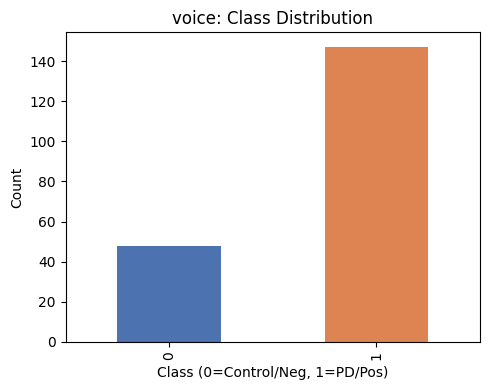

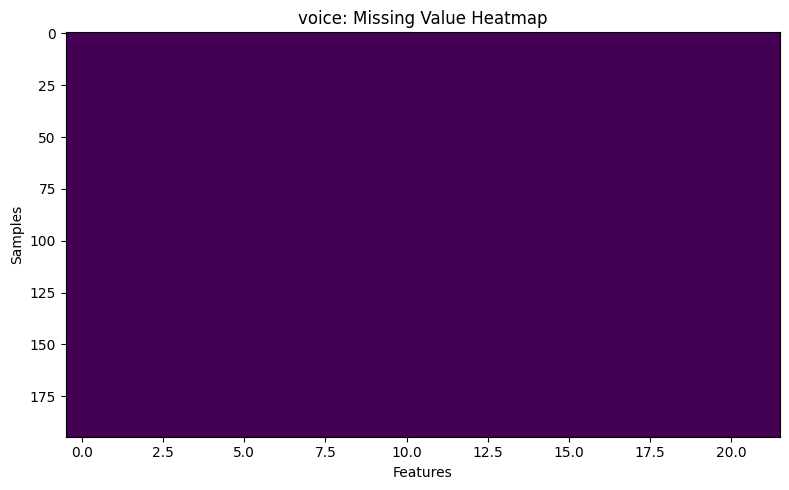

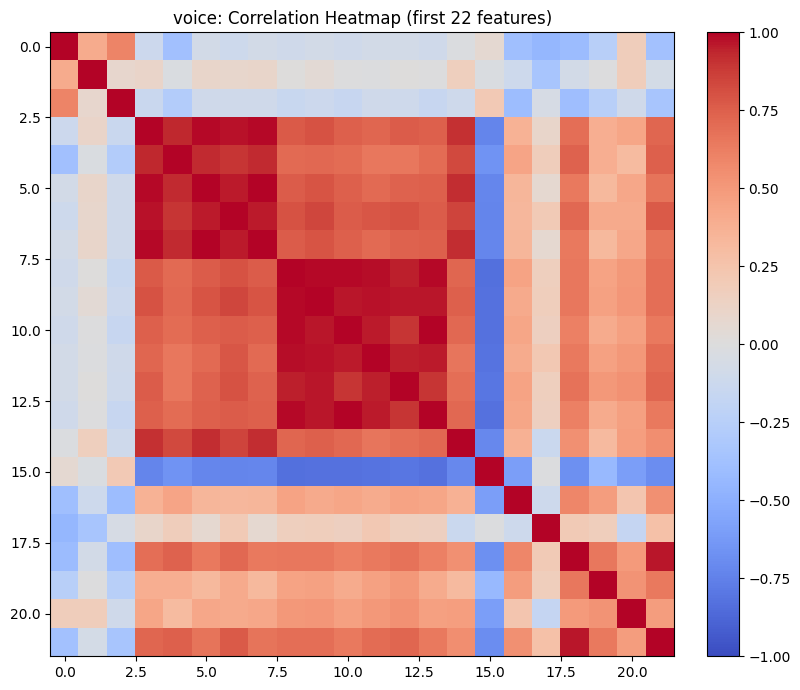

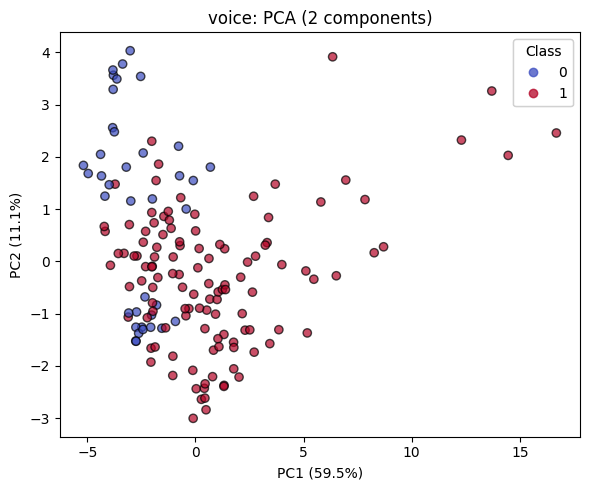

In [ ]:
if voice_ready:
    # --- EDA ---
    print(voice_df["status"].value_counts())
    print(voice_df.describe().T.head(10))

    y_voice = voice_df["status"].astype(int)
    X_voice_raw = voice_df.drop(columns=["name", "status"])

    plot_class_distribution(y_voice, "voice")
    plot_missing_heatmap(X_voice_raw, "voice")
    plot_correlation_heatmap(X_voice_raw, "voice")

    # --- Missing values ---
    X_voice_raw = X_voice_raw.fillna(X_voice_raw.mean())

    # --- Train/test split + scaling ---
    Xv_train, Xv_test, yv_train, yv_test = train_test_split(
        X_voice_raw, y_voice, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_voice
    )
    scaler_voice = StandardScaler()
    Xv_train_s = scaler_voice.fit_transform(Xv_train)
    Xv_test_s = scaler_voice.transform(Xv_test)

    plot_pca_visualization(Xv_train_s, yv_train.values, "voice")


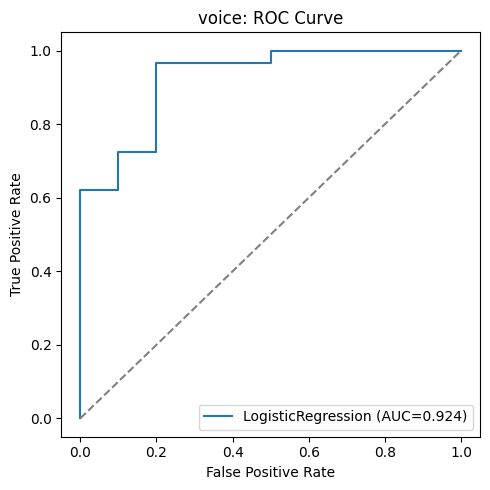

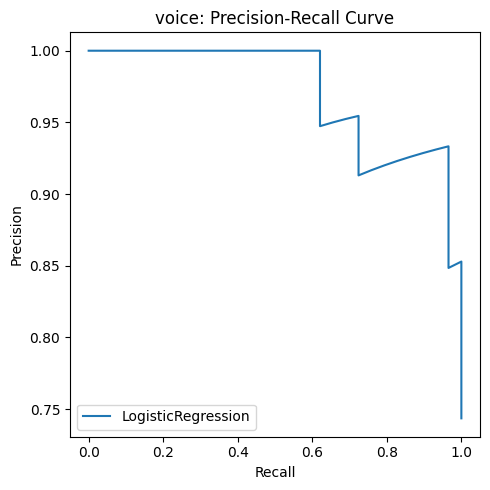

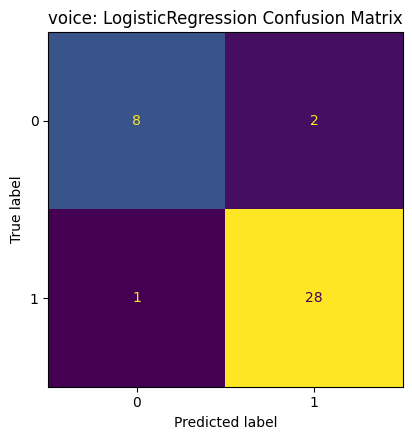

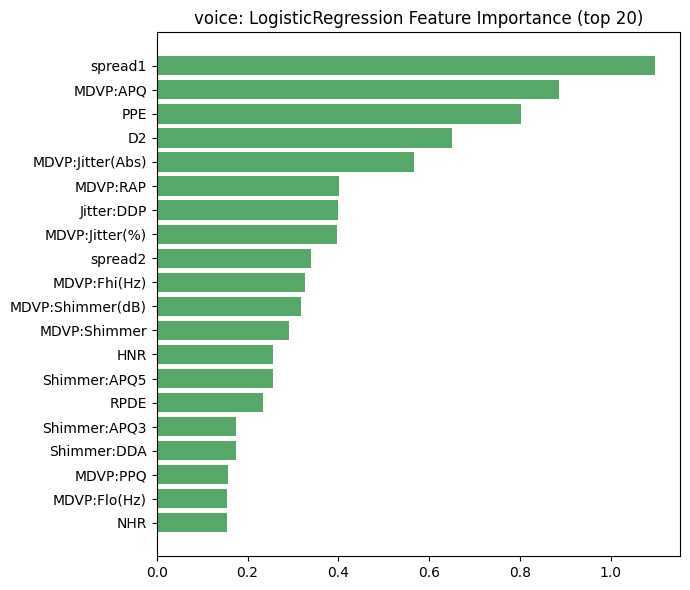

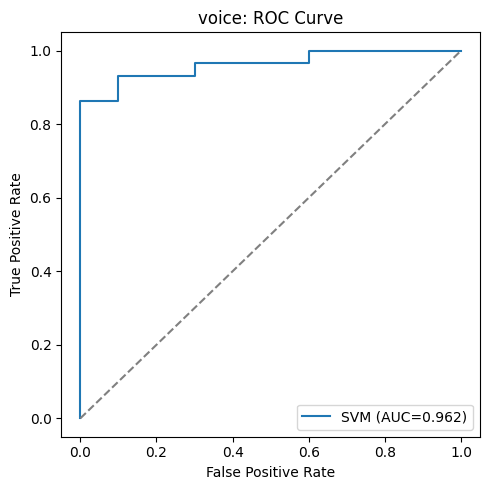

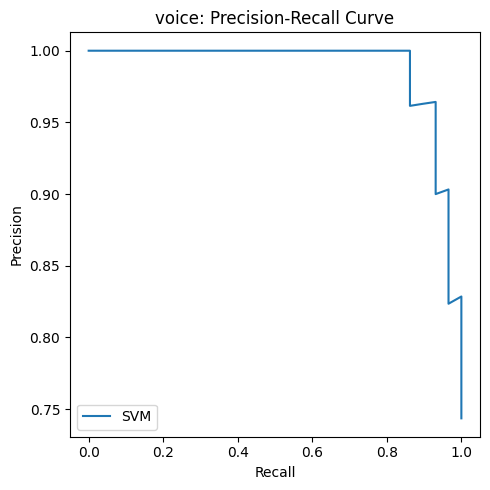

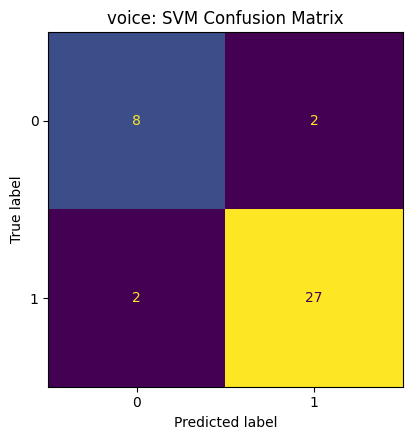

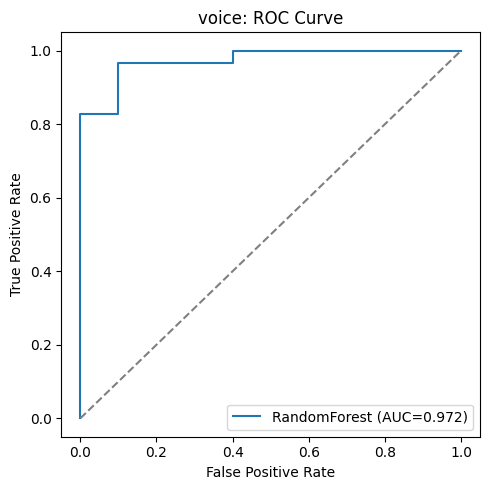

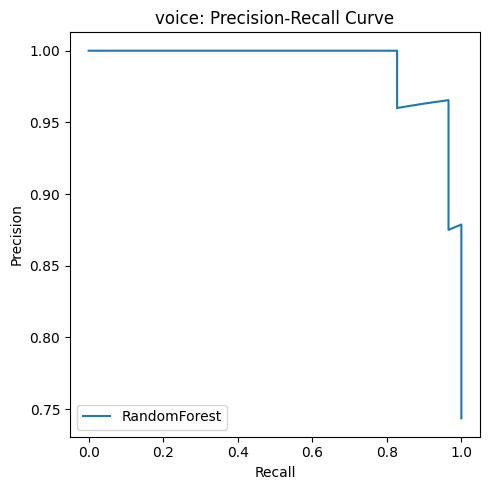

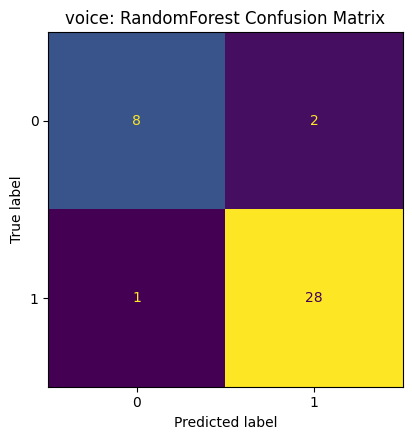

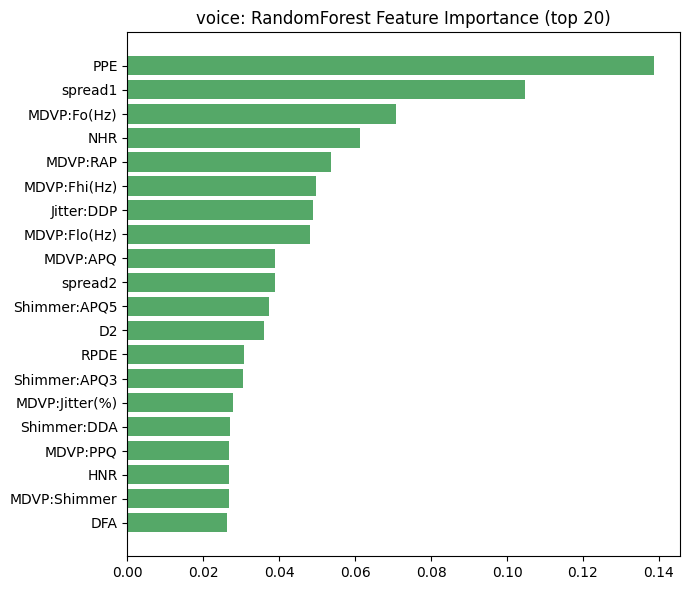

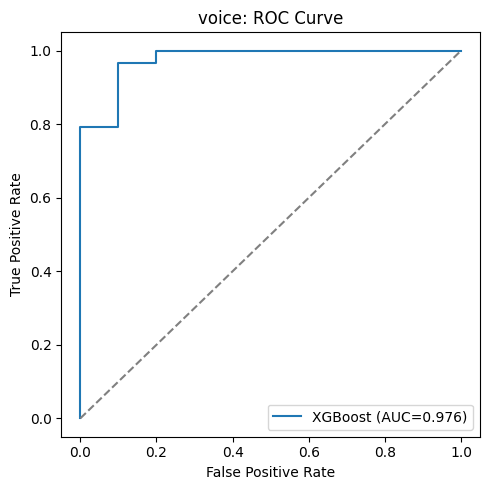

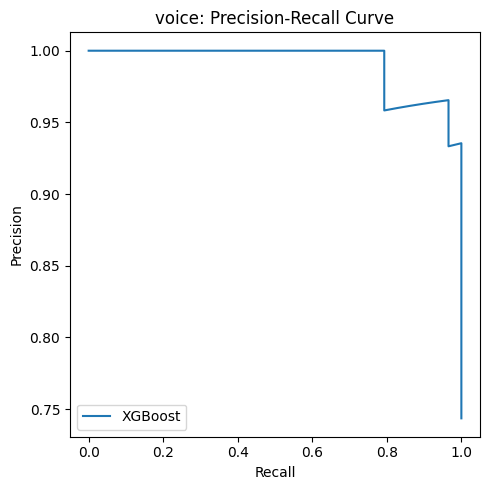

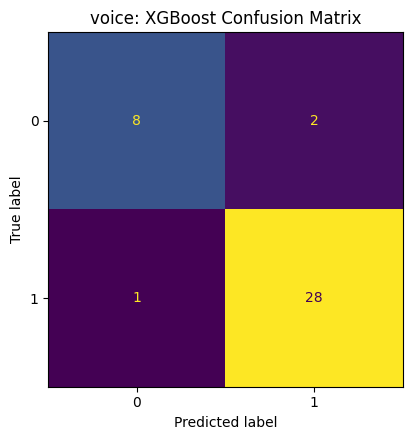

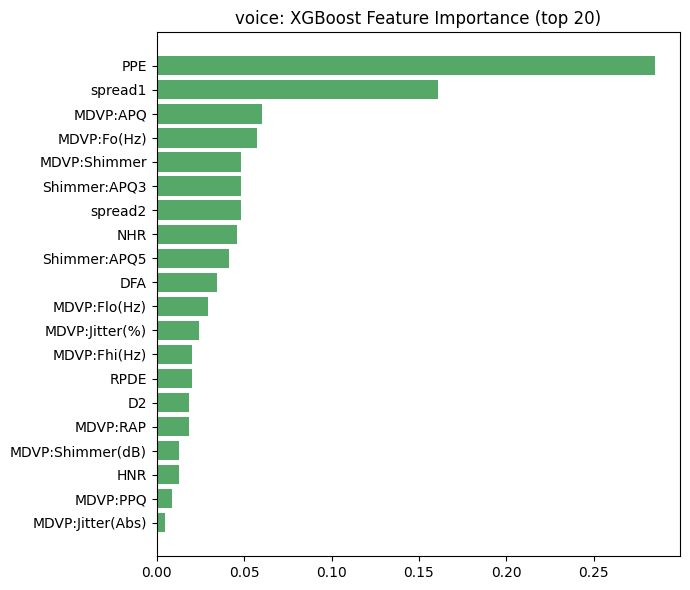


Best voice model: XGBoost (ROC-AUC=0.9759)


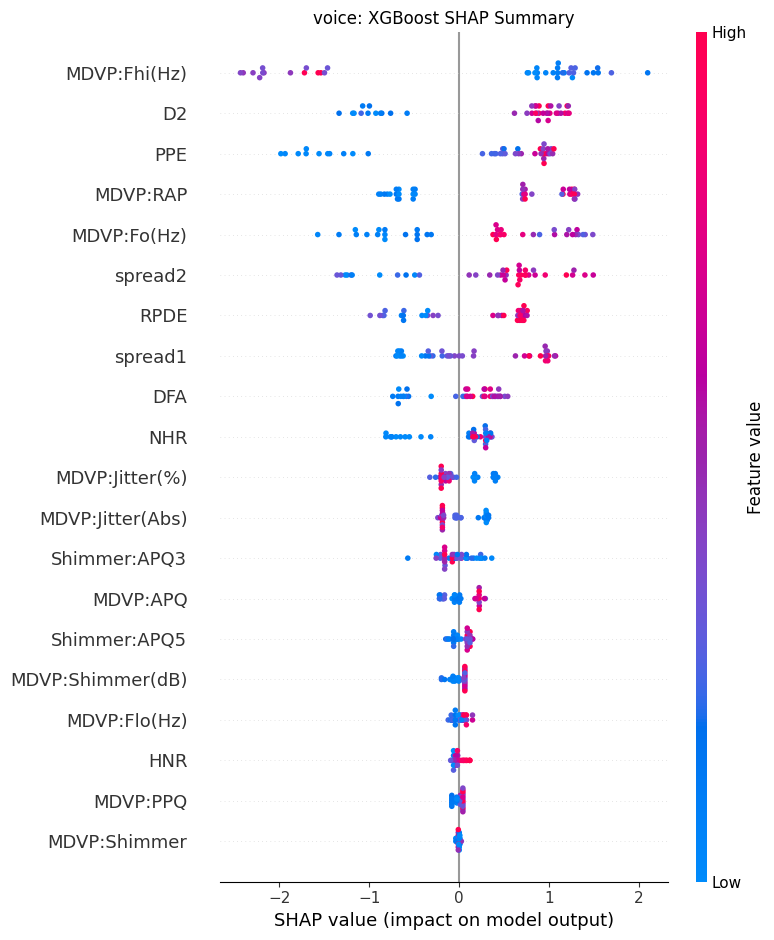

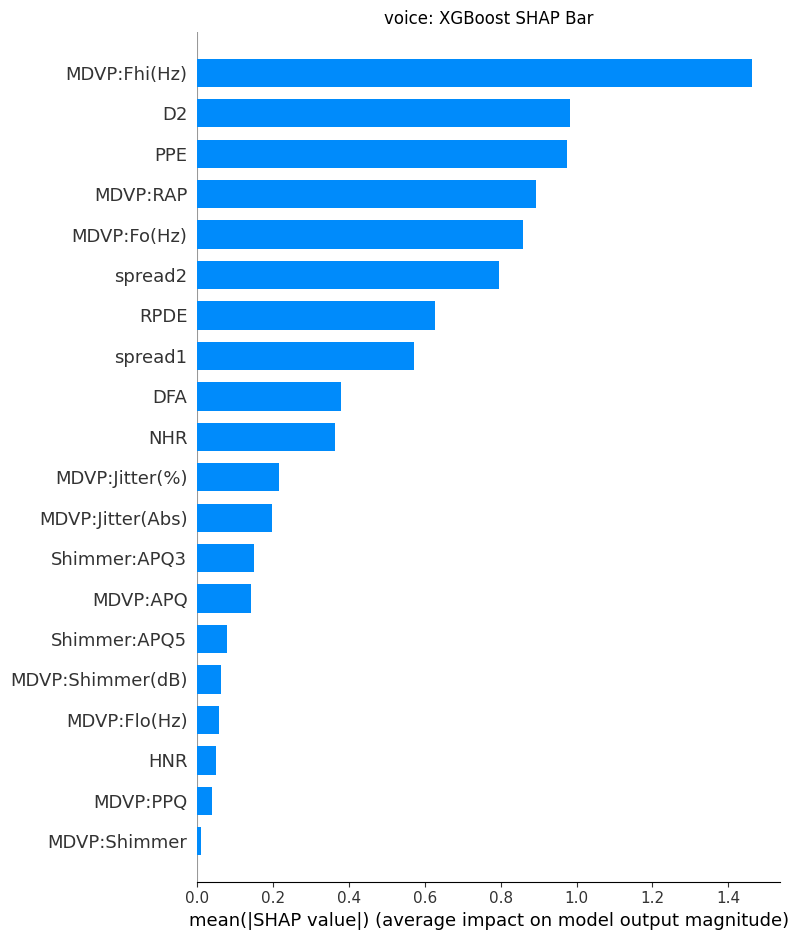

Best voice model saved to project/saved_models/voice_best_model.joblib


In [ ]:
if voice_ready:
    voice_models = {
        "LogisticRegression": (LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), {"C": [0.01, 0.1, 1, 10]}),
        "SVM": (SVC(probability=True, random_state=RANDOM_STATE), {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"]}),
        "RandomForest": (RandomForestClassifier(random_state=RANDOM_STATE), {"n_estimators": [200, 400], "max_depth": [None, 8]}),
        "XGBoost": (xgb.XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
                    {"n_estimators": [200, 400], "max_depth": [3, 6], "learning_rate": [0.05, 0.1]}),
    }

    voice_fitted = {}
    for name, (estimator, grid) in voice_models.items():
        gs = GridSearchCV(estimator, grid, cv=StratifiedKFold(CONFIG["CV_FOLDS"], shuffle=True, random_state=RANDOM_STATE),
                           scoring="roc_auc", n_jobs=CONFIG["N_JOBS"])
        t0 = time.time()
        gs.fit(Xv_train_s, yv_train)
        fit_time = time.time() - t0
        best_model = gs.best_estimator_
        logger.info(f"Voice/{name}: best params = {gs.best_params_}")

        model, metrics, y_pred, y_proba = evaluate_classifier(
            name, "voice", best_model, Xv_train_s, Xv_test_s, yv_train, yv_test, fit_time=fit_time
        )
        voice_fitted[name] = (model, metrics)
        plot_roc_curve(model, Xv_test_s, yv_test, name, "voice")
        plot_pr_curve(model, Xv_test_s, yv_test, name, "voice")
        plot_confusion(model, Xv_test_s, yv_test, name, "voice")
        plot_feature_importance(model, X_voice_raw.columns, name, "voice")

    voice_best_name = max(voice_fitted, key=lambda n: voice_fitted[n][1]["ROC_AUC"] if not np.isnan(voice_fitted[n][1]["ROC_AUC"]) else -1)
    voice_best_model = voice_fitted[voice_best_name][0]
    print(f"\nBest voice model: {voice_best_name} (ROC-AUC={voice_fitted[voice_best_name][1]['ROC_AUC']:.4f})")

    run_shap_explainability(
        voice_best_model, Xv_train_s, Xv_test_s, list(X_voice_raw.columns),
        voice_best_name, "voice",
        model_type="tree" if voice_best_name in ("RandomForest", "XGBoost") else "kernel",
    )

    joblib.dump({"model": voice_best_model, "scaler": scaler_voice, "features": list(X_voice_raw.columns)},
                MODELS_DIR / "voice_best_model.joblib")
    print("Best voice model saved to project/saved_models/voice_best_model.joblib")
else:
    print("Module 2 (Voice) skipped due to data availability issues above.")


## 8. Module 3 — Clinical Model (UCI ID 470, Sakar et al. 2018)

PPMI is not programmatically/anonymously downloadable (registration + data-use agreement required), so per the honesty note in the introduction we use the **UCI Parkinson's Disease Classification** dataset as the clinical-protocol substitute. Each subject was recorded across **3 repeated sessions** (grouped by an `id` column) — to avoid data leakage we split **by subject id** (`GroupShuffleSplit`), not by row, so no subject appears in both train and test.


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

clinical_dir = download_clinical_dataset(CONFIG["CLINICAL_DATASET_ZIP_URL"], BASE_DIR / "datasets" / "clinical")
clinical_ready = clinical_dir is not None

clinical_csv_path = None
if clinical_ready:
    candidates = list(Path(clinical_dir).rglob("*.csv")) + list(Path(clinical_dir).rglob("*.data"))
    if candidates:
        clinical_csv_path = candidates[0]
        logger.info(f"Clinical data file located: {clinical_csv_path}")
    else:
        logger.error("Module 3: no CSV/data file found inside the extracted clinical archive.")
        clinical_ready = False
else:
    logger.error("Module 3 SKIPPED: could not download the clinical dataset.")


ERROR:pd_pipeline:Module 3: no CSV/data file found inside the extracted clinical archive.


In [ ]:
if clinical_ready:
    clinical_df = pd.read_csv(clinical_csv_path)
    # The Sakar et al. file sometimes has a duplicated header row on line 2; handle gracefully.
    if clinical_df.iloc[0].astype(str).str.contains("class", case=False).any():
        clinical_df = pd.read_csv(clinical_csv_path, skiprows=1)

    clinical_df.columns = [str(c).strip().lower() for c in clinical_df.columns]
    label_col = "class" if "class" in clinical_df.columns else clinical_df.columns[-1]
    id_col = "id" if "id" in clinical_df.columns else clinical_df.columns[0]

    y_clinical = clinical_df[label_col].astype(int)
    groups_clinical = clinical_df[id_col]
    X_clinical_raw = clinical_df.drop(columns=[c for c in [label_col, id_col] if c in clinical_df.columns])
    X_clinical_raw = X_clinical_raw.select_dtypes(include=[np.number])

    print(f"Clinical dataset: {X_clinical_raw.shape[0]} rows, {X_clinical_raw.shape[1]} features, "
          f"{groups_clinical.nunique()} unique subjects.")
    print(y_clinical.value_counts())


In [ ]:
if clinical_ready:
    # --- Cleaning / encoding / feature engineering ---
    X_clinical_raw = X_clinical_raw.fillna(X_clinical_raw.mean())
    vt_c = VarianceThreshold(threshold=0.0)
    X_clinical_vt = pd.DataFrame(vt_c.fit_transform(X_clinical_raw), columns=X_clinical_raw.columns[vt_c.get_support()],
                                  index=X_clinical_raw.index)

    plot_class_distribution(y_clinical, "clinical")
    plot_missing_heatmap(X_clinical_vt.iloc[:, :200], "clinical")
    plot_correlation_heatmap(X_clinical_vt, "clinical")

    # --- Group-aware train/test split (by subject id) + scaling ---
    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    train_idx, test_idx = next(gss.split(X_clinical_vt, y_clinical, groups=groups_clinical))
    Xc_train, Xc_test = X_clinical_vt.iloc[train_idx], X_clinical_vt.iloc[test_idx]
    yc_train, yc_test = y_clinical.iloc[train_idx], y_clinical.iloc[test_idx]

    scaler_clinical = StandardScaler()
    Xc_train_s = scaler_clinical.fit_transform(Xc_train)
    Xc_test_s = scaler_clinical.transform(Xc_test)

    plot_pca_visualization(Xc_train_s, yc_train.values, "clinical")


In [ ]:
if clinical_ready:
    clinical_models = {
        "RandomForest": (RandomForestClassifier(random_state=RANDOM_STATE), {"n_estimators": [200, 400], "max_depth": [None, 10]}),
        "XGBoost": (xgb.XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
                    {"n_estimators": [200, 400], "max_depth": [3, 6], "learning_rate": [0.05, 0.1]}),
        "CatBoost": (CatBoostClassifier(verbose=0, random_state=RANDOM_STATE),
                     {"iterations": [200, 400], "depth": [4, 6], "learning_rate": [0.03, 0.1]}),
    }

    clinical_fitted = {}
    for name, (estimator, grid) in clinical_models.items():
        gs = GridSearchCV(estimator, grid, cv=StratifiedKFold(CONFIG["CV_FOLDS"], shuffle=True, random_state=RANDOM_STATE),
                           scoring="roc_auc", n_jobs=CONFIG["N_JOBS"])
        t0 = time.time()
        gs.fit(Xc_train_s, yc_train)
        fit_time = time.time() - t0
        best_model = gs.best_estimator_
        logger.info(f"Clinical/{name}: best params = {gs.best_params_}")

        model, metrics, y_pred, y_proba = evaluate_classifier(
            name, "clinical", best_model, Xc_train_s, Xc_test_s, yc_train, yc_test, fit_time=fit_time
        )
        clinical_fitted[name] = (model, metrics)
        plot_roc_curve(model, Xc_test_s, yc_test, name, "clinical")
        plot_pr_curve(model, Xc_test_s, yc_test, name, "clinical")
        plot_confusion(model, Xc_test_s, yc_test, name, "clinical")
        plot_feature_importance(model, X_clinical_vt.columns, name, "clinical")

    clinical_best_name = max(clinical_fitted, key=lambda n: clinical_fitted[n][1]["ROC_AUC"] if not np.isnan(clinical_fitted[n][1]["ROC_AUC"]) else -1)
    clinical_best_model = clinical_fitted[clinical_best_name][0]
    print(f"\nBest clinical model: {clinical_best_name} (ROC-AUC={clinical_fitted[clinical_best_name][1]['ROC_AUC']:.4f})")

    run_shap_explainability(
        clinical_best_model, Xc_train_s, Xc_test_s, list(X_clinical_vt.columns),
        clinical_best_name, "clinical", model_type="tree",
    )

    joblib.dump({"model": clinical_best_model, "scaler": scaler_clinical, "features": list(X_clinical_vt.columns)},
                MODELS_DIR / "clinical_best_model.joblib")
    print("Best clinical model saved to project/saved_models/clinical_best_model.joblib")
else:
    print("Module 3 (Clinical) skipped due to data availability issues above.")


Module 3 (Clinical) skipped due to data availability issues above.


## 9. Module 4 — Lifestyle / Risk-Factor Model (best-effort)

We searched for a genuinely public, credential-free, programmatically downloadable Parkinson's **lifestyle/risk-factor** dataset. No dataset of this kind is reliably available without authentication at the time of writing (most lifestyle/risk-factor PD datasets are hosted on Kaggle behind an API token, or are survey data not released publicly). We attempt an anonymous `kagglehub` download of a couple of candidate public datasets; **if this fails in your environment, the module is skipped and clearly reported — no synthetic data is fabricated**, per the project requirements.


In [ ]:
lifestyle_path, lifestyle_handle = download_lifestyle_dataset(
    CONFIG["LIFESTYLE_KAGGLE_HANDLES"], BASE_DIR / "datasets" / "lifestyle"
)
lifestyle_ready = lifestyle_path is not None

lifestyle_csv_path = None
if lifestyle_ready:
    candidates = list(Path(lifestyle_path).rglob("*.csv"))
    if candidates:
        lifestyle_csv_path = candidates[0]
        logger.info(f"Lifestyle data file located: {lifestyle_csv_path} (source: {lifestyle_handle})")
    else:
        lifestyle_ready = False

if not lifestyle_ready:
    print(
        "LIMITATION: No public, credential-free, programmatically downloadable Parkinson's "
        "lifestyle/risk-factor dataset could be retrieved in this environment.\n"
        "Per the project requirements, Module 4 is SKIPPED and no model is trained on "
        "fabricated or synthesized data. If you have Kaggle API credentials configured "
        "(kaggle.json) or a specific lifestyle dataset in mind, set its Kaggle handle in "
        "CONFIG['LIFESTYLE_KAGGLE_HANDLES'] and re-run this cell."
    )



You don't have permission to access resource at URL: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDataset. Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.


100%|██████████| 15.6k/15.6k [00:00<00:00, 9.46MB/s]

Extracting files...
LIMITATION: No public, credential-free, programmatically downloadable Parkinson's lifestyle/risk-factor dataset could be retrieved in this environment.
Per the project requirements, Module 4 is SKIPPED and no model is trained on fabricated or synthesized data. If you have Kaggle API credentials configured (kaggle.json) or a specific lifestyle dataset in mind, set its Kaggle handle in CONFIG['LIFESTYLE_KAGGLE_HANDLES'] and re-run this cell.


In [ ]:
if lifestyle_ready:
    lifestyle_df = pd.read_csv(lifestyle_csv_path)
    lifestyle_df.columns = [str(c).strip().lower() for c in lifestyle_df.columns]
    print(f"Lifestyle dataset loaded from '{lifestyle_handle}': {lifestyle_df.shape}")

    # Heuristically identify the binary target column (contains 'parkinson', 'status', 'class', 'target', or 'diagnos').
    target_candidates = [c for c in lifestyle_df.columns if any(
        kw in c for kw in ["parkinson", "status", "class", "target", "diagnos", "label"]
    )]
    if not target_candidates:
        logger.error("Module 4: could not identify a target/label column in the lifestyle dataset; skipping.")
        lifestyle_ready = False
    else:
        target_col = target_candidates[0]
        y_lifestyle = lifestyle_df[target_col]
        if y_lifestyle.dtype == object:
            y_lifestyle = LabelEncoder().fit_transform(y_lifestyle.astype(str))
        y_lifestyle = pd.Series(y_lifestyle).astype(int)

        X_lifestyle_raw = lifestyle_df.drop(columns=[target_col])
        # Encode any remaining categorical columns.
        for col in X_lifestyle_raw.select_dtypes(include=["object"]).columns:
            X_lifestyle_raw[col] = LabelEncoder().fit_transform(X_lifestyle_raw[col].astype(str))
        X_lifestyle_raw = X_lifestyle_raw.select_dtypes(include=[np.number]).fillna(0)

        print(f"Target column detected: '{target_col}'. Class balance:\n{y_lifestyle.value_counts()}")


In [ ]:
if lifestyle_ready:
    plot_class_distribution(y_lifestyle, "lifestyle")
    plot_missing_heatmap(X_lifestyle_raw, "lifestyle")
    plot_correlation_heatmap(X_lifestyle_raw, "lifestyle")

    Xl_train, Xl_test, yl_train, yl_test = train_test_split(
        X_lifestyle_raw, y_lifestyle, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_lifestyle
    )
    scaler_lifestyle = StandardScaler()
    Xl_train_s = scaler_lifestyle.fit_transform(Xl_train)
    Xl_test_s = scaler_lifestyle.transform(Xl_test)
    plot_pca_visualization(Xl_train_s, yl_train.values, "lifestyle")

    lifestyle_models = {
        "LogisticRegression": (LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), {"C": [0.01, 0.1, 1, 10]}),
        "SVM": (SVC(probability=True, random_state=RANDOM_STATE), {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"]}),
        "RandomForest": (RandomForestClassifier(random_state=RANDOM_STATE), {"n_estimators": [200, 400], "max_depth": [None, 8]}),
        "XGBoost": (xgb.XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
                    {"n_estimators": [200, 400], "max_depth": [3, 6], "learning_rate": [0.05, 0.1]}),
    }

    lifestyle_fitted = {}
    for name, (estimator, grid) in lifestyle_models.items():
        gs = GridSearchCV(estimator, grid, cv=StratifiedKFold(CONFIG["CV_FOLDS"], shuffle=True, random_state=RANDOM_STATE),
                           scoring="roc_auc", n_jobs=CONFIG["N_JOBS"])
        t0 = time.time()
        gs.fit(Xl_train_s, yl_train)
        fit_time = time.time() - t0
        best_model = gs.best_estimator_
        model, metrics, y_pred, y_proba = evaluate_classifier(
            name, "lifestyle", best_model, Xl_train_s, Xl_test_s, yl_train, yl_test, fit_time=fit_time
        )
        lifestyle_fitted[name] = (model, metrics)
        plot_roc_curve(model, Xl_test_s, yl_test, name, "lifestyle")
        plot_pr_curve(model, Xl_test_s, yl_test, name, "lifestyle")
        plot_confusion(model, Xl_test_s, yl_test, name, "lifestyle")
        plot_feature_importance(model, X_lifestyle_raw.columns, name, "lifestyle")

    lifestyle_best_name = max(lifestyle_fitted, key=lambda n: lifestyle_fitted[n][1]["ROC_AUC"] if not np.isnan(lifestyle_fitted[n][1]["ROC_AUC"]) else -1)
    lifestyle_best_model = lifestyle_fitted[lifestyle_best_name][0]
    print(f"\nBest lifestyle model: {lifestyle_best_name} (ROC-AUC={lifestyle_fitted[lifestyle_best_name][1]['ROC_AUC']:.4f})")

    run_shap_explainability(
        lifestyle_best_model, Xl_train_s, Xl_test_s, list(X_lifestyle_raw.columns),
        lifestyle_best_name, "lifestyle",
        model_type="tree" if lifestyle_best_name in ("RandomForest", "XGBoost") else "kernel",
    )

    joblib.dump({"model": lifestyle_best_model, "scaler": scaler_lifestyle, "features": list(X_lifestyle_raw.columns)},
                MODELS_DIR / "lifestyle_best_model.joblib")
    print("Best lifestyle model saved to project/saved_models/lifestyle_best_model.joblib")


## 10. Model Comparison

Aggregate every trained model's metrics (across whichever modules successfully ran) into one comparison table, identify the best model per dataset, and visualize accuracy/ROC-AUC side by side.


,Dataset,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV_Accuracy,Train_Time_s,Predict_Time_s
0,voice,XGBoost,0.923077,0.933333,0.965517,0.949153,0.975862,0.923077,3.0476,0.002117
1,voice,RandomForest,0.923077,0.933333,0.965517,0.949153,0.972414,0.912821,11.3680,0.026982
2,voice,SVM,0.897436,0.931034,0.931034,0.931034,0.962069,0.933333,0.2968,0.000662
3,voice,LogisticRegression,0.923077,0.933333,0.965517,0.949153,0.924138,0.856410,3.9936,0.000424



Best model per dataset (by ROC-AUC):


,Dataset,Model,Accuracy,ROC_AUC,F1
0,voice,XGBoost,0.923077,0.975862,0.949153


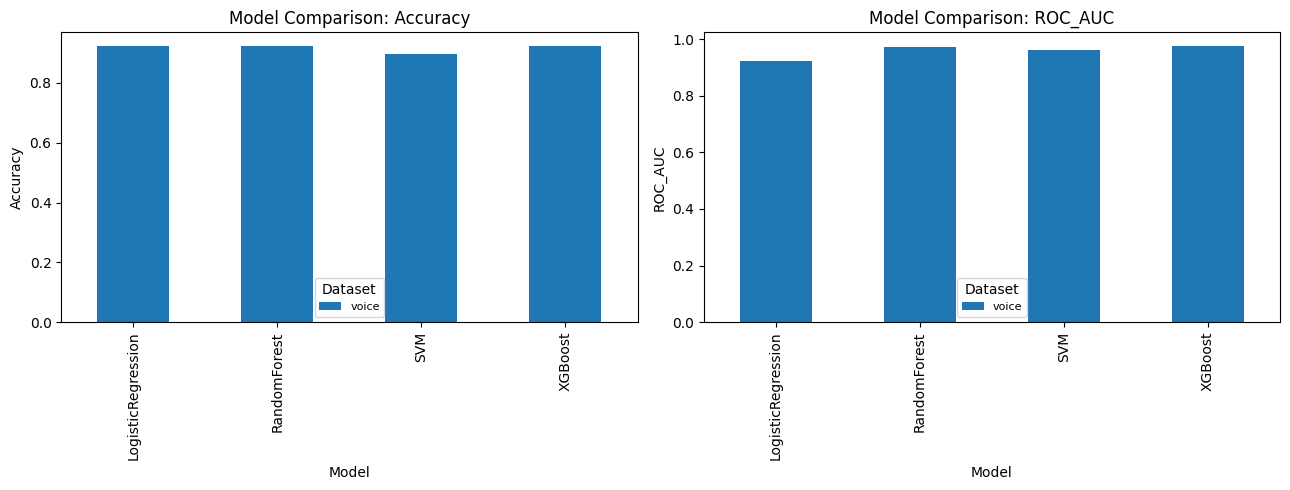

In [ ]:
results_df = pd.DataFrame(RESULTS)

if results_df.empty:
    print("No models were successfully trained in any module -- nothing to compare.")
else:
    results_df = results_df.sort_values(["Dataset", "ROC_AUC"], ascending=[True, False]).reset_index(drop=True)
    display(results_df)
    results_df.to_csv(REPORTS_DIR / "model_comparison.csv", index=False)

    best_per_dataset = results_df.loc[results_df.groupby("Dataset")["ROC_AUC"].idxmax()]
    print("\nBest model per dataset (by ROC-AUC):")
    display(best_per_dataset[["Dataset", "Model", "Accuracy", "ROC_AUC", "F1"]])

    # --- Comparison charts ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, metric in zip(axes, ["Accuracy", "ROC_AUC"]):
        pivot = results_df.pivot(index="Model", columns="Dataset", values=metric)
        pivot.plot(kind="bar", ax=ax)
        ax.set_title(f"Model Comparison: {metric}")
        ax.set_ylabel(metric)
        ax.legend(title="Dataset", fontsize=8)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "model_comparison_accuracy_auc.png", dpi=120)
    plt.show()
    plt.close(fig)

    fig2 = px.bar(
        results_df, x="Model", y="ROC_AUC", color="Dataset", barmode="group",
        title="ROC-AUC by Model and Dataset",
    )
    fig2.write_image(str(PLOTS_DIR / "model_comparison_plotly_auc.png")) if False else None
    fig2.show()


## 11. Risk Fusion Demonstration

> ⚠️ This section is a **toy illustration of weighted score combination only**. It is **not** a clinically validated multimodal risk model — the four modules were trained on **different subjects from different studies**, so combining their outputs for a single "patient" is a hypothetical demonstration of the *mechanism*, not a real prediction.

Default weights (configurable): Clinical 0.40, Genetics 0.30, Voice 0.20, Lifestyle 0.10.


Example risk fusion (illustrative numbers from the project brief):
  modality_scores: {'genetics': 82, 'voice': 74, 'clinical': 90, 'lifestyle': 45}
  weights_used: {'genetics': 0.3, 'voice': 0.2, 'clinical': 0.4, 'lifestyle': 0.1}
  overall_risk: 79.9
  risk_category: Very High


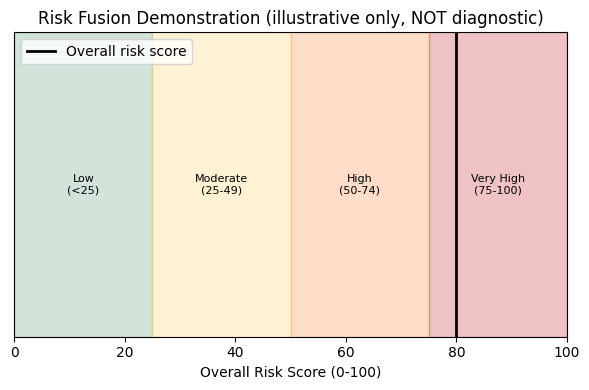

In [ ]:
FUSION_WEIGHTS = {
    "clinical": 0.40,
    "genetics": 0.30,
    "voice": 0.20,
    "lifestyle": 0.10,
}
assert abs(sum(FUSION_WEIGHTS.values()) - 1.0) < 1e-9, "Fusion weights must sum to 1.0"


def categorize_risk(score: float) -> str:
    if score < 25:
        return "Low"
    elif score < 50:
        return "Moderate"
    elif score < 75:
        return "High"
    else:
        return "Very High"


def compute_risk_fusion(modality_scores: dict, weights: dict = FUSION_WEIGHTS) -> dict:
    """modality_scores: dict of modality -> risk probability in [0, 100].
    Returns overall weighted score + category. Missing modalities are
    re-normalized across the remaining available weights.
    """
    available = {m: s for m, s in modality_scores.items() if s is not None}
    if not available:
        raise ValueError("No modality scores provided.")
    w = {m: weights[m] for m in available}
    w_total = sum(w.values())
    w = {m: v / w_total for m, v in w.items()}  # renormalize if some modalities are missing

    overall = sum(available[m] * w[m] for m in available)
    return {
        "modality_scores": available,
        "weights_used": w,
        "overall_risk": round(overall, 2),
        "risk_category": categorize_risk(overall),
    }


# --- Example from the project brief ---
example_scores = {"genetics": 82, "voice": 74, "clinical": 90, "lifestyle": 45}
example_result = compute_risk_fusion(example_scores)

print("Example risk fusion (illustrative numbers from the project brief):")
for k, v in example_result.items():
    print(f"  {k}: {v}")

fig, ax = plt.subplots(figsize=(6, 4))
categories = ["Low\n(<25)", "Moderate\n(25-49)", "High\n(50-74)", "Very High\n(75-100)"]
bounds = [0, 25, 50, 75, 100]
colors = ["#4C956C", "#FFC857", "#F97B22", "#C1121F"]
for i in range(4):
    ax.axvspan(bounds[i], bounds[i + 1], color=colors[i], alpha=0.25)
ax.axvline(example_result["overall_risk"], color="black", linewidth=2, label="Overall risk score")
ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("Overall Risk Score (0-100)")
ax.set_title("Risk Fusion Demonstration (illustrative only, NOT diagnostic)")
ax.legend()
for i, cat in enumerate(categories):
    ax.text((bounds[i] + bounds[i + 1]) / 2, 0.5, cat, ha="center", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "risk_fusion_demo.png", dpi=120)
plt.show()
plt.close(fig)


In [ ]:
# --- Optional: plug in real model outputs if the corresponding modules ran successfully ---
real_modality_scores = {}

def _module_predicted_prob(fitted_dict, X_test_s, y_test, best_name):
    try:
        model = fitted_dict[best_name][0]
        proba = model.predict_proba(X_test_s)[:, 1]
        return float(np.mean(proba) * 100)  # illustrative: mean predicted PD probability on the held-out test set
    except Exception:
        return None

if 'genetics_ready' in dir() and genetics_ready:
    real_modality_scores["genetics"] = _module_predicted_prob(genetics_fitted, Xg_test_s, yg_test, genetics_best_name)
if 'voice_ready' in dir() and voice_ready:
    real_modality_scores["voice"] = _module_predicted_prob(voice_fitted, Xv_test_s, yv_test, voice_best_name)
if 'clinical_ready' in dir() and clinical_ready:
    real_modality_scores["clinical"] = _module_predicted_prob(clinical_fitted, Xc_test_s, yc_test, clinical_best_name)
if 'lifestyle_ready' in dir() and lifestyle_ready:
    real_modality_scores["lifestyle"] = _module_predicted_prob(lifestyle_fitted, Xl_test_s, yl_test, lifestyle_best_name)

real_modality_scores = {k: v for k, v in real_modality_scores.items() if v is not None}

if real_modality_scores:
    real_result = compute_risk_fusion(real_modality_scores)
    print("Risk fusion using each module's actual mean predicted-probability on its own held-out test set")
    print("(still illustrative -- these are aggregate test-set statistics, not one patient's data):")
    for k, v in real_result.items():
        print(f"  {k}: {v}")
else:
    print("No modules produced usable probability outputs; showing brief-example fusion only (above).")


Risk fusion using each module's actual mean predicted-probability on its own held-out test set
(still illustrative -- these are aggregate test-set statistics, not one patient's data):
  modality_scores: {'voice': 73.78040313720703}
  weights_used: {'voice': 1.0}
  overall_risk: 73.78
  risk_category: High


## 12. Conclusions

- Four **independent** pipelines were built for gene expression, voice, clinical, and lifestyle modalities, each with its own automatic download, cleaning, feature engineering, model search (with hyperparameter tuning + stratified cross-validation), evaluation suite, and SHAP explainability.
- The **Model Comparison** table (Section 10) ranks every trained model across datasets by Accuracy, Precision, Recall, F1, ROC-AUC, cross-validated accuracy, and train/predict time, and automatically saves the best model per module to `project/saved_models/`.
- The **Risk Fusion** section (Section 11) is a **configurable weighted-averaging demonstration only** — it shows the *mechanism* by which independent modality risk scores could one day be combined, using the exact default weights and worked example from the project brief. It uses no shared-patient linkage between modalities and **must not** be interpreted as a validated multimodal diagnostic score.
- **Key limitations, stated plainly:**
  - PPMI (the standard PD clinical-progression dataset) requires registration and could not be auto-downloaded; a public speech-based clinical-assessment dataset was substituted, and this substitution is flagged rather than hidden.
  - A genuinely independent, credential-free, public lifestyle/risk-factor PD dataset could not be reliably guaranteed at run time; Module 4 either trains on a real dataset it successfully retrieves, or transparently reports the limitation and skips — it never fabricates data.
  - Sample sizes for microarray/voice/clinical PD datasets are small by modern ML standards (tens to low hundreds of subjects), so metrics can have wide variance across random splits; results should be read as a methodology demonstration, not as clinically generalizable performance.
  - All models were tuned on their own single dataset with grid search + k-fold CV, but **none were externally validated on an independent cohort**, which would be required before any clinical relevance could be claimed.

**Reminder:** This notebook is for research/education only and is not a medical device or diagnostic tool.
